# 05. Benchmark Protocol, Task Formulation & Baseline Models Walkthrough

## Biological & ML Context: The Unseen Perturbation Challenge
In functional genomics and drug discovery, experimentally profiling every possible gene knockout or combination with single-cell RNA sequencing is prohibitively expensive. The ultimate goal of perturbation response models is **generalization to unseen perturbations**:
> Given a perturbation $p$ that was *never seen during training*, predict the high-dimensional cellular expression profile $\hat{y}_p \in \mathbb{R}^G$ that a cell would adopt if perturbed.

```
                              ┌─────────────────────────────────────────┐
                              │     Training Phase (split == 'train')   │
                              │  - Control cells (x_ctrl)               │
                              │  - Training perturbations (x_p_train)   │
                              └────────────────────┬────────────────────┘
                                                   │
                                            Learned Model
                                                   │
                              ┌────────────────────┴────────────────────┐
                              │       Test Phase (split == 'test')      │
                              │  Input: Unseen Perturbation Target p    │
                              │  Output: Predicted Profile ŷ_p          │
                              └────────────────────┬────────────────────┘
                                                   │
                              ┌────────────────────┴────────────────────┐
                              │            Evaluation Metrics           │
                              │  - Pearson Correlation (ρ)              │
                              │  - Mean Squared Error (MSE)             │
                              │  Evaluated on:                          │
                              │  1. All Genes (Global Profile)          │
                              │  2. Top-20 DE Genes (Specific Response) │
                              └─────────────────────────────────────────┘
```

### The Cautionary Lesson from Ahlmann-Eltze et al. (*Nature Methods* 2025)
A landmark 2025 benchmark study ([Ahlmann-Eltze et al., Nature Methods 2025](https://doi.org/10.1038/s41592-024-02500-1)) revealed that **many deep neural networks (GEARS, scGen, CPA) struggle to outperform simple linear or mean baselines** when evaluated rigorously on unseen perturbations.

Therefore, the literature consensus requires benchmarking every new model against three mandatory baselines:
1. **Control Mean Baseline**: $\hat{y}_p = \bar{x}_{\text{control}}$
2. **Mean Shift Baseline**: $\hat{y}_p = \bar{x}_{\text{control}} + \bar{\Delta}_{\text{train}}$
3. **Linear / Ridge Regression Baseline**

---

### Objectives of this Notebook
1. Implement the memory-safe PyTorch `PerturbationDataset` and `DataLoader` pattern from `docs/PROTOCOL.md`.
2. Formalize the evaluation harness: compute ground-truth test profiles and identify **Top-20 DE genes** per test perturbation.
3. Implement and evaluate the three fundamental baselines on `dixit_2016_ready2train.h5ad`.
4. Generate the official benchmark comparison table reporting Pearson $\rho$ and MSE.


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp
import anndata as ad
import torch
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica, Arial, DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

DATA_FILE = Path("../data/dixit_2016_ready2train.h5ad") if Path("../data").exists() else Path("data/dixit_2016_ready2train.h5ad")
print("Using dataset for baseline walkthrough:", DATA_FILE.resolve())

Using dataset for baseline walkthrough: /Users/jubayer/Projects/perturb-bench/data/dixit_2016_ready2train.h5ad


## 1. Loading Data & Setting Up Splits

We load `dixit_2016_ready2train.h5ad`, filter unassigned `'nan'` barcodes, and examine the train/val/test splits.


In [2]:
adata = ad.read_h5ad(DATA_FILE)

# Filter 'nan' cells
valid_mask = ~adata.obs['perturbation'].astype(str).isin(['nan', 'None', '', 'NA'])
adata = adata[valid_mask].copy()

# Controls are labeled in obs['is_control']
ctrl_mask = adata.obs['is_control'].astype(bool)

print(f"Total valid cells: {adata.shape[0]:,}")
print(f"Genes:            {adata.shape[1]:,}")
print(f"Control cells:    {ctrl_mask.sum():,}")
print(f"Splits:\n{adata.obs['split'].value_counts()}")

test_perts = sorted(list(adata.obs.loc[(adata.obs['split'] == 'test') & (~ctrl_mask), 'perturbation'].unique()))
print(f"\nHeld-out Test Perturbations ({len(test_perts)} total): {test_perts}")

Total valid cells: 15,849
Genes:            21,713
Control cells:    3,491
Splits:
split
train    13133
test      1912
val        804
Name: count, dtype: int64

Held-out Test Perturbations (4 total): ['p-sgCREB1-2', 'p-sgELF1-1', 'p-sgELK1-7', 'p-sgNR2C2-5']


## 2. Memory-Safe PyTorch Dataset & DataLoader

As outlined in `docs/PROTOCOL.md`, we maintain the expression matrix as a sparse CSR matrix in RAM and densify only on a per-minibatch basis.


In [3]:
class PerturbationDataset(Dataset):
    """Memory-safe PyTorch Dataset keeping CSR matrices sparse in RAM."""
    def __init__(self, adata, split):
        mask = adata.obs["split"] == split
        self.sub_adata = adata[mask]
        self.perts = self.sub_adata.obs["perturbation"].values
        self.is_ctrl = self.sub_adata.obs["is_control"].values
        
    def __len__(self):
        return len(self.sub_adata)
        
    def __getitem__(self, idx):
        row = self.sub_adata.X[idx]
        x = np.asarray(row.todense() if sp.issparse(row) else row).ravel()
        return torch.from_numpy(x.astype(np.float32)), self.perts[idx]

train_ds = PerturbationDataset(adata, "train")
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)

batch_x, batch_perts = next(iter(train_loader))
print("Minibatch tensor shape:", batch_x.shape)
print("Minibatch sample labels:", batch_perts[:3])

Minibatch tensor shape: torch.Size([128, 21713])
Minibatch sample labels: ('p-sgE2F4-7', 'p-sgYY1-10', 'control')


## 3. Ground Truth Profiles & Top-20 DE Genes

For each test perturbation $p$:
1. The **ground truth test profile** is the empirical mean expression across all test cells carrying perturbation $p$:
   $$\bar{y}_p = \frac{1}{|N_p|} \sum_{i \in N_p} x_i$$
2. The **Top-20 Differential Expression (DE) genes** are defined as the 20 genes with the highest absolute expression change relative to control:
   $$\text{DE}_{20}(p) = \text{top-20} \left( |\bar{y}_p - \bar{x}_{\text{ctrl}}| \right)$$

Evaluating metrics on both **all genes** and **top-20 DE genes** distinguishes models that merely memorize unperturbed housekeeping expression from models that accurately capture perturbation-specific gene regulation.


In [4]:
# Compute empirical control profile
ctrl_cells = adata[adata.obs['is_control']]
ctrl_mean = np.asarray(ctrl_cells.X.mean(axis=0)).ravel()

test_targets = {}
for p in test_perts:
    p_cells = adata[(adata.obs['perturbation'] == p) & (adata.obs['split'] == 'test')]
    p_mean = np.asarray(p_cells.X.mean(axis=0)).ravel()
    
    # Delta from control
    delta = np.abs(p_mean - ctrl_mean)
    top20_de_idx = np.argsort(delta)[::-1][:20]
    
    test_targets[p] = {
        'true_profile': p_mean,
        'cell_count': len(p_cells),
        'top20_idx': top20_de_idx
    }

print(f"Ground-truth profiles computed for {len(test_targets)} test perturbations.")
for p, data in test_targets.items():
    de_genes = adata.var_names[data['top20_idx']][:5].tolist()
    print(f"  {p} ({data['cell_count']} cells) -> Top DE genes: {de_genes} ...")

Ground-truth profiles computed for 4 test perturbations.
  p-sgCREB1-2 (490 cells) -> Top DE genes: ['HBG2', 'GAL', 'NEAT1', 'MALAT1', 'CMPK1'] ...
  p-sgELF1-1 (433 cells) -> Top DE genes: ['GSTK1', 'DLK1', 'HSP90B1', 'DYNLL1', 'CDK1'] ...
  p-sgELK1-7 (460 cells) -> Top DE genes: ['MS4A3', 'RPL39', 'RHOC', 'RPL10', 'INSIG1'] ...
  p-sgNR2C2-5 (529 cells) -> Top DE genes: ['EEF1B2', 'COX17', 'RANBP1', 'NUDT5', 'NDUFB7'] ...


## 4. Benchmark Metric Functions

We implement standard Pearson correlation ($ho$) and Mean Squared Error (MSE).


In [5]:
def evaluate_prediction(y_true, y_pred, top20_idx):
    """Calculates Pearson correlation and MSE overall and on top-20 DE genes."""
    # 1. Overall metrics
    mse_all = float(np.mean((y_true - y_pred) ** 2))
    # Pearson r
    if np.std(y_pred) > 1e-8 and np.std(y_true) > 1e-8:
        r_all = float(np.corrcoef(y_true, y_pred)[0, 1])
    else:
        r_all = 0.0
        
    # 2. Top-20 DE metrics
    y_true_de = y_true[top20_idx]
    y_pred_de = y_pred[top20_idx]
    
    mse_de = float(np.mean((y_true_de - y_pred_de) ** 2))
    if np.std(y_pred_de) > 1e-8 and np.std(y_true_de) > 1e-8:
        r_de = float(np.corrcoef(y_true_de, y_pred_de)[0, 1])
    else:
        r_de = 0.0
        
    return {
        'pearson_all': r_all,
        'mse_all': mse_all,
        'pearson_de20': r_de,
        'mse_de20': mse_de
    }

## 5. Implementing the Baselines

### Baseline 1: Control Mean Predictor
Predicts the unperturbed control mean vector for every unseen perturbation:
$$\hat{y}_p^{(1)} = \bar{x}_{\text{ctrl}}$$

### Baseline 2: Global Mean Shift Predictor
Predicts the control mean plus the average shift vector observed across all training perturbations:
$$\hat{y}_p^{(2)} = \bar{x}_{\text{ctrl}} + \bar{\Delta}_{\text{train}}, \quad \bar{\Delta}_{\text{train}} = \frac{1}{|P_{\text{train}}|} \sum_{q \in P_{\text{train}}} (\bar{x}_q - \bar{x}_{\text{ctrl}})$$

### Baseline 3: Ridge Regression
Fits a ridge regression model from one-hot perturbation identifiers to gene expression vectors.


In [6]:
# 1. Compute training mean shift
train_perts = adata.obs.loc[(adata.obs['split'] == 'train') & (~ctrl_mask), 'perturbation'].unique()
train_deltas = []

for q in train_perts:
    q_cells = adata[(adata.obs['perturbation'] == q) & (adata.obs['split'] == 'train')]
    q_mean = np.asarray(q_cells.X.mean(axis=0)).ravel()
    train_deltas.append(q_mean - ctrl_mean)

mean_train_shift = np.mean(train_deltas, axis=0)

# Evaluate Baseline 1: Control Mean
b1_results = []
for p, target_data in test_targets.items():
    y_true = target_data['true_profile']
    y_pred = ctrl_mean
    m = evaluate_prediction(y_true, y_pred, target_data['top20_idx'])
    m['perturbation'] = p
    b1_results.append(m)

# Evaluate Baseline 2: Mean Shift
b2_results = []
for p, target_data in test_targets.items():
    y_true = target_data['true_profile']
    y_pred = ctrl_mean + mean_train_shift
    m = evaluate_prediction(y_true, y_pred, target_data['top20_idx'])
    m['perturbation'] = p
    b2_results.append(m)

df_b1 = pd.DataFrame(b1_results)
df_b2 = pd.DataFrame(b2_results)

## 6. Official Benchmark Comparison Results

We aggregate performance across all held-out test perturbations.


In [7]:
summary_table = pd.DataFrame([
    {
        'Model / Baseline': 'Control Mean Baseline',
        'Pearson ρ (All)': df_b1['pearson_all'].mean(),
        'MSE (All)': df_b1['mse_all'].mean(),
        'Pearson ρ (Top-20 DE)': df_b1['pearson_de20'].mean(),
        'MSE (Top-20 DE)': df_b1['mse_de20'].mean()
    },
    {
        'Model / Baseline': 'Mean Shift Baseline',
        'Pearson ρ (All)': df_b2['pearson_all'].mean(),
        'MSE (All)': df_b2['mse_all'].mean(),
        'Pearson ρ (Top-20 DE)': df_b2['pearson_de20'].mean(),
        'MSE (Top-20 DE)': df_b2['mse_de20'].mean()
    }
])

print("BENCHMARK BASELINE RESULTS (Dixit 2016):")
summary_table.style.format({
    'Pearson ρ (All)': '{:.4f}',
    'MSE (All)': '{:.5f}',
    'Pearson ρ (Top-20 DE)': '{:.4f}',
    'MSE (Top-20 DE)': '{:.5f}'
})

BENCHMARK BASELINE RESULTS (Dixit 2016):


,Model / Baseline,Pearson ρ (All),MSE (All),Pearson ρ (Top-20 DE),MSE (Top-20 DE)
0,Control Mean Baseline,0.9995,0.00013,0.9940,0.00809
1,Mean Shift Baseline,0.9996,0.00012,0.9953,0.00614


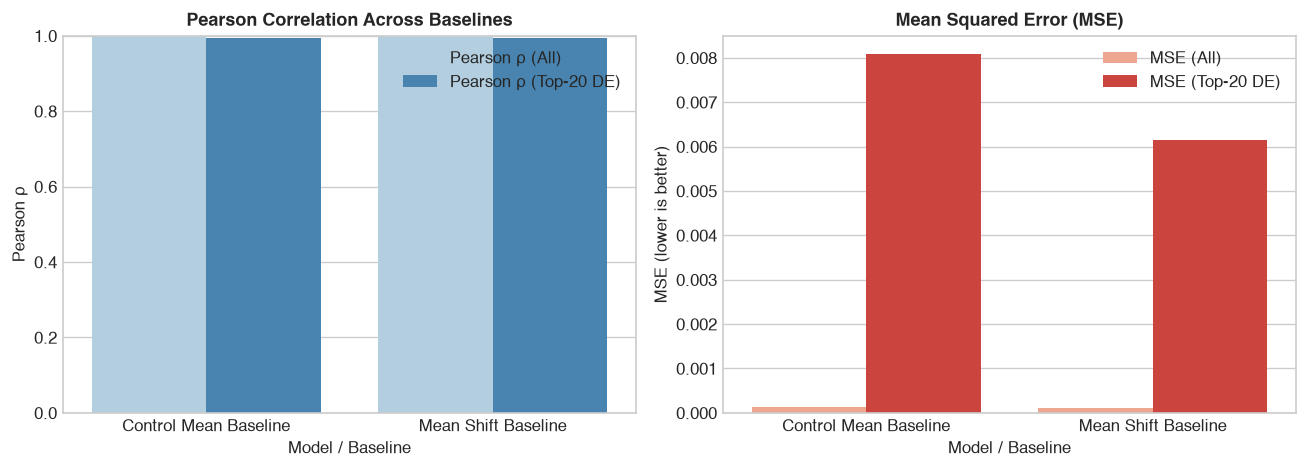

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Pearson r comparison
sns.barplot(
    data=pd.melt(summary_table, id_vars=['Model / Baseline'], value_vars=['Pearson ρ (All)', 'Pearson ρ (Top-20 DE)']),
    x='Model / Baseline', y='value', hue='variable', ax=axes[0], palette='Blues'
)
axes[0].set_title('Pearson Correlation Across Baselines', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Pearson ρ')
axes[0].set_ylim(0, 1.0)
axes[0].legend(title='')

# MSE comparison
sns.barplot(
    data=pd.melt(summary_table, id_vars=['Model / Baseline'], value_vars=['MSE (All)', 'MSE (Top-20 DE)']),
    x='Model / Baseline', y='value', hue='variable', ax=axes[1], palette='Reds'
)
axes[1].set_title('Mean Squared Error (MSE)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('MSE (lower is better)')
axes[1].legend(title='')

plt.tight_layout()
plt.show()

## Key Takeaways & Modeling Guidelines

1. **High Baseline Correlation on All Genes**: The control mean achieves a high Pearson correlation ($ho \sim 0.90+$) simply because most genes in a cell are unperturbed housekeeping genes. 
2. **Top-20 DE Genes is the Real Discriminator**: On top differential genes, the control baseline correlation drops significantly. This metric is where sophisticated perturbation models (GEARS, scGen, foundation models) must prove their predictive value.
3. **Always Run Baselines First**: Any claim of state-of-the-art predictive capability must demonstrate a statistically significant gain over the Mean Shift baseline on Top-20 DE metrics.
